# Relatorio final: Deteccao e Quantificacao de Doencas em Folhas

Este notebook consolida a Fase 6 do projeto **Deteccao e Quantificacao de Doencas em Folhas de Plantas**, usando processamento classico de imagens com OpenCV. O objetivo e documentar a metodologia, reproduzir visualizacoes reais do pipeline e discutir os resultados obtidos na validacao em lote.

O pipeline usa limiares HSV, morfologia matematica, contornos e metricas de area. Nao ha uso de deep learning. Todas as tabelas, graficos e paineis abaixo sao produzidos por execucao real sobre o dataset local em `SELECTED_DATA_DIR` e pelo arquivo consolidado `results/csv_results.csv` gerado pela F5.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# O notebook fica em plant_disease/notebooks; o pacote fica no diretorio raiz do projeto.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from plant_disease.config import SELECTED_DATA_DIR, RESULTS_DIR
from plant_disease.pipeline import process_image, PipelineConfig
from plant_disease.stage4_analysis import SeverityThresholds
from plant_disease.stage5_validation import (
    BatchConfig,
    analyze_failures,
    collect_dataset_paths,
    export_results_csv,
    process_batch,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

CSV_PATH = RESULTS_DIR / "csv_results.csv"
print(f"Projeto: {PROJECT_ROOT}")
print(f"Dataset selecionado: {SELECTED_DATA_DIR}")
print(f"CSV de resultados: {CSV_PATH}")

Projeto: C:\Users\Renef\Documents\Trabalho_Processamento_Imagem
Dataset selecionado: C:\Users\Renef\Documents\Trabalho_Processamento_Imagem\plant_disease\data\selected
CSV de resultados: C:\Users\Renef\Documents\Trabalho_Processamento_Imagem\plant_disease\results\csv_results.csv


## Introducao

O problema tratado e estimar automaticamente a area foliar afetada por doenca em imagens de tomate e batata. A abordagem escolhida foi deliberadamente classica: primeiro a folha e isolada, depois tons associados a lesoes sao segmentados dentro da folha, e por fim a severidade e inferida pelo percentual de pixels lesionados em relacao aos pixels da folha.

Essa decisao torna o metodo simples, interpretavel e rapido, mas tambem torna o resultado dependente de escolhas manuais como ranges HSV, tamanho de kernel morfologico e limiares fixos de severidade. Por isso a discussao final amarra os erros observados diretamente a essas decisoes tecnicas.

## Metodologia (F6.1)

### Dataset

O dataset usado esta organizado em `SELECTED_DATA_DIR`, definido em `plant_disease.config`. A estrutura esperada e uma pasta por categoria, onde o nome da pasta codifica especie e estado da folha. Neste projeto foram usadas as categorias `potato_early_blight`, `potato_healthy`, `potato_late_blight`, `tomato_early_blight`, `tomato_healthy` e `tomato_late_blight`. As categorias com sufixo `healthy` sao tratadas como saudaveis; as demais sao tratadas como doentes na validacao em lote.

A coleta dos caminhos e feita por `collect_dataset_paths`, que percorre `SELECTED_DATA_DIR`, infere a categoria pela subpasta imediata e retorna pares `(path, category)`. Essa etapa e usada por `process_batch` na F5.

### Pre-processamento

O pre-processamento esta em `stage1_preproc.py`. A funcao `gaussian_blur` aplica `cv2.GaussianBlur` com kernel padrao 5x5 para reduzir ruido local antes da segmentacao. Em seguida, `resize_to_size` padroniza a imagem para 256x256 pixels, o que torna os kernels morfologicos, areas de contorno e percentuais comparaveis entre imagens. A funcao `preprocess` integra essas duas operacoes e e chamada por `process_image`.

### Conversao de cor

As imagens sao lidas pelo OpenCV em BGR. Para analise, `bgr_to_hsv`, em `utils/color.py`, converte a imagem pre-processada para HSV. O HSV foi escolhido porque separa matiz, saturacao e valor, permitindo regras mais diretas para folhas verdes e lesoes amareladas/marrons. Para exibicao em matplotlib, `bgr_to_rgb` converte BGR para RGB.

### Segmentacao da folha

A segmentacao principal da folha esta em `stage2_leaf_seg.py`. A funcao `segment_leaf` usa `cv2.inRange` no HSV com o intervalo padrao de verde: H entre 35 e 85, S entre 30 e 255, V entre 40 e 255. Depois aplica abertura e fechamento morfologicos com kernel eliptico 5x5 para remover ruido e preencher pequenas falhas.

Como alternativa documentada, `segment_leaf_otsu` aplica limiarizacao automatica de Otsu em imagem em tons de cinza. No pipeline integrado, a rota usada e HSV. Apos a mascara inicial, `extract_largest_contour` seleciona e preenche o maior contorno, assumindo que a maior regiao verde corresponde a folha. Por fim, `apply_mask` pode extrair a regiao foliar com `cv2.bitwise_and`.

### Deteccao de lesoes

A deteccao de lesoes esta em `stage3_lesion.py`. A funcao `segment_lesions_hsv` combina tres ranges HSV: amarelo, marrom-baixo e marrom-alto. O amarelo cobre lesoes iniciais/clorose. O marrom precisa de dois ranges porque o canal H do OpenCV e circular, variando de 0 a 179: tons avermelhados/marrons podem aparecer proximos de 0 e tambem proximos de 179. Por isso o projeto usa `brown_low_lower`/`brown_low_upper` e `brown_high_lower`/`brown_high_upper`, unidos com `cv2.bitwise_or`.

Depois da mascara bruta, `intersect_with_leaf` restringe a lesao a area da folha, evitando contar fundo como doenca. `refine_lesion_mask` aplica abertura e fechamento com kernel 3x3. `find_lesion_contours` detecta contornos externos e descarta regioes menores que `min_contour_area=10`. A funcao `detect_lesions` integra essa sequencia: segmentar lesoes, intersectar com folha, refinar e encontrar contornos.

### Calculo de severidade

A analise quantitativa esta em `stage4_analysis.py`. `count_mask_pixels` conta pixels brancos em uma mascara binaria. `calculate_affected_percentage` calcula `lesion_px / leaf_px * 100`, limitando o resultado ao intervalo 0-100 e evitando divisao por zero. `classify_severity` usa quatro niveis com os limiares padrao definidos em `SeverityThresholds`: abaixo de 5% = `Saudavel`; 5% a menos de 20% = `Leve`; 20% a menos de 50% = `Moderada`; 50% ou mais = `Grave`. `calculate_h_histogram` calcula o histograma normalizado do canal H, geralmente restrito a mascara da folha.

A funcao `create_result_panel` monta o painel final com quatro subplots: imagem original, mascara da folha, mascara de lesao e histograma H. Esse painel e usado nas visualizacoes da F4, F5 e neste relatorio.

### Pipeline integrado e validacao em lote

O pipeline ponta a ponta esta em `pipeline.py`, na funcao `process_image`. Ela carrega a imagem com `load_image`, executa `preprocess`, converte para HSV com `bgr_to_hsv`, segmenta a folha com `segment_leaf` e `extract_largest_contour`, detecta lesoes com `detect_lesions`, calcula metricas com `analyze` e, se configurado, cria o painel com `create_result_panel`.

A validacao em lote esta em `stage5_validation.py`. `process_batch` aplica `process_image` a todos os caminhos coletados e nao interrompe o lote quando uma imagem falha. `analyze_failures` compara a severidade prevista com a categoria inferida da pasta, separando falsos positivos e falsos negativos. `export_results_csv` grava `results/csv_results.csv` com as colunas `image`, `class`, `leaf_px`, `lesion_px`, `pct` e `severity`.

### Parametros avaliados nesta F6

A configuracao de referencia mantem os parametros originais das fases anteriores, inclusive os limiares de severidade 5/20/50. Como a validacao mostrou muitos falsos negativos em folhas doentes com percentual detectado abaixo de 5%, este notebook tambem testa limiares alternativos para `leve_min` (2%, 1% e 0,5%) usando `PipelineConfig` customizado, sem alterar os arquivos-fonte. O CSV principal permanece gerado com a configuracao padrao para preservar a comparabilidade com a F5.

In [2]:
dataset_paths = collect_dataset_paths(SELECTED_DATA_DIR)
category_counts = (
    pd.DataFrame(dataset_paths, columns=["path", "class"])
    .groupby("class")
    .size()
    .rename("n_images")
    .reset_index()
    .sort_values("class")
)
print(f"Total de imagens encontradas: {len(dataset_paths)}")
category_counts

Total de imagens encontradas: 301


,class,n_images
0,potato_early_blight,50
1,potato_healthy,50
2,potato_late_blight,50
3,tomato_early_blight,50
4,tomato_healthy,51
5,tomato_late_blight,50


## Resultados e visualizacoes (F6.2)

A celula seguinte executa a validacao em lote com a configuracao padrao do projeto e exporta novamente `csv_results.csv`. Esta e a execucao real usada pelas tabelas e graficos abaixo.

In [3]:
start = time.time()
results = process_batch(SELECTED_DATA_DIR, BatchConfig())
export_ok = export_results_csv(results, CSV_PATH)
failures = analyze_failures(results)
elapsed = time.time() - start

print(f"Imagens processadas: {len(results)}")
print(f"CSV exportado: {export_ok} -> {CSV_PATH}")
print(f"Tempo de execucao: {elapsed:.2f} s")
print(f"Avaliadas: {failures['n_avaliados']} | Erros: {failures['n_erros']}")
print(f"Falsos positivos: {failures['n_false_positives']} ({failures['fp_rate']:.2%} das saudaveis avaliadas)")
print(f"Falsos negativos: {failures['n_false_negatives']} ({failures['fn_rate']:.2%} das doentes avaliadas)")

Imagens processadas: 301
CSV exportado: True -> C:\Users\Renef\Documents\Trabalho_Processamento_Imagem\plant_disease\results\csv_results.csv
Tempo de execucao: 1.17 s
Avaliadas: 300 | Erros: 1
Falsos positivos: 1 (0.99% das saudaveis avaliadas)
Falsos negativos: 130 (65.33% das doentes avaliadas)


In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Linhas no CSV: {len(df)}")
df.head(12)

Linhas no CSV: 301


,image,class,leaf_px,lesion_px,pct,severity
0,00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Earl...,potato_early_blight,39619.0,19.0,0.05,Saudavel
1,02578b86-b234-4ac0-9bc3-691b5610e2bf___RS_Earl...,potato_early_blight,34229.0,2277.0,6.65,Leve
2,065fc68f-88c9-4fc3-b0a6-a6f5e1072eaa___RS_Earl...,potato_early_blight,37607.0,1755.0,4.67,Saudavel
3,13cfb9dc-8951-44c0-8c16-e96fd6ccc659___RS_Earl...,potato_early_blight,33180.0,4093.0,12.34,Leve
4,1b4304a9-88c2-4c09-bfea-830fa162a35a___RS_Earl...,potato_early_blight,39094.0,4058.0,10.38,Leve
5,1f80f111-6a3e-4dfc-8456-0f3e9a19ae10___RS_Earl...,potato_early_blight,33924.0,1358.0,4.00,Saudavel
6,2639ad26-c7e9-4bd6-8000-c002f676a4c6___RS_Earl...,potato_early_blight,24292.0,718.0,2.96,Saudavel
7,2771e005-3cb4-4e12-8868-80adca5ce02a___RS_Earl...,potato_early_blight,40807.0,3509.0,8.60,Leve
8,2d344be7-2d5f-4d27-aeb2-b92c8191b877___RS_Earl...,potato_early_blight,34094.0,5193.0,15.23,Leve
9,33019904-ac3b-4083-a192-ce4092758ddd___RS_Earl...,potato_early_blight,37507.0,3229.0,8.61,Leve


In [5]:
summary = (
    df.groupby("class", dropna=False)
    .agg(
        n=("image", "count"),
        pct_mean=("pct", "mean"),
        pct_median=("pct", "median"),
        pct_min=("pct", "min"),
        pct_max=("pct", "max"),
    )
    .round(2)
)
summary

,n,pct_mean,pct_median,pct_min,pct_max
class,,,,,
potato_early_blight,50,10.43,8.59,0.00,71.05
potato_healthy,50,0.03,0.00,0.00,0.42
potato_late_blight,50,3.76,0.80,0.04,46.58
tomato_early_blight,50,2.35,1.02,0.00,14.35
tomato_healthy,51,0.79,0.16,0.00,9.91
tomato_late_blight,50,3.73,1.56,0.00,25.68


In [6]:
severity_order = ["Saudavel", "Leve", "Moderada", "Grave", "Erro"]
severity_table = pd.crosstab(df["class"], df["severity"]).reindex(columns=severity_order, fill_value=0)
severity_table

severity,Saudavel,Leve,Moderada,Grave,Erro
class,,,,,
potato_early_blight,11,35,3,1,0
potato_healthy,50,0,0,0,0
potato_late_blight,40,9,1,0,0
tomato_early_blight,44,6,0,0,0
tomato_healthy,50,1,0,0,0
tomato_late_blight,35,13,1,0,1


### Paineis completos em imagens reais

A seguir, `process_image` e executado em seis imagens reais, uma por categoria. Cada painel mostra imagem original, mascara da folha, mascara de lesao e histograma do canal H. Os titulos incluem categoria, nome do arquivo, percentual afetado e severidade prevista.

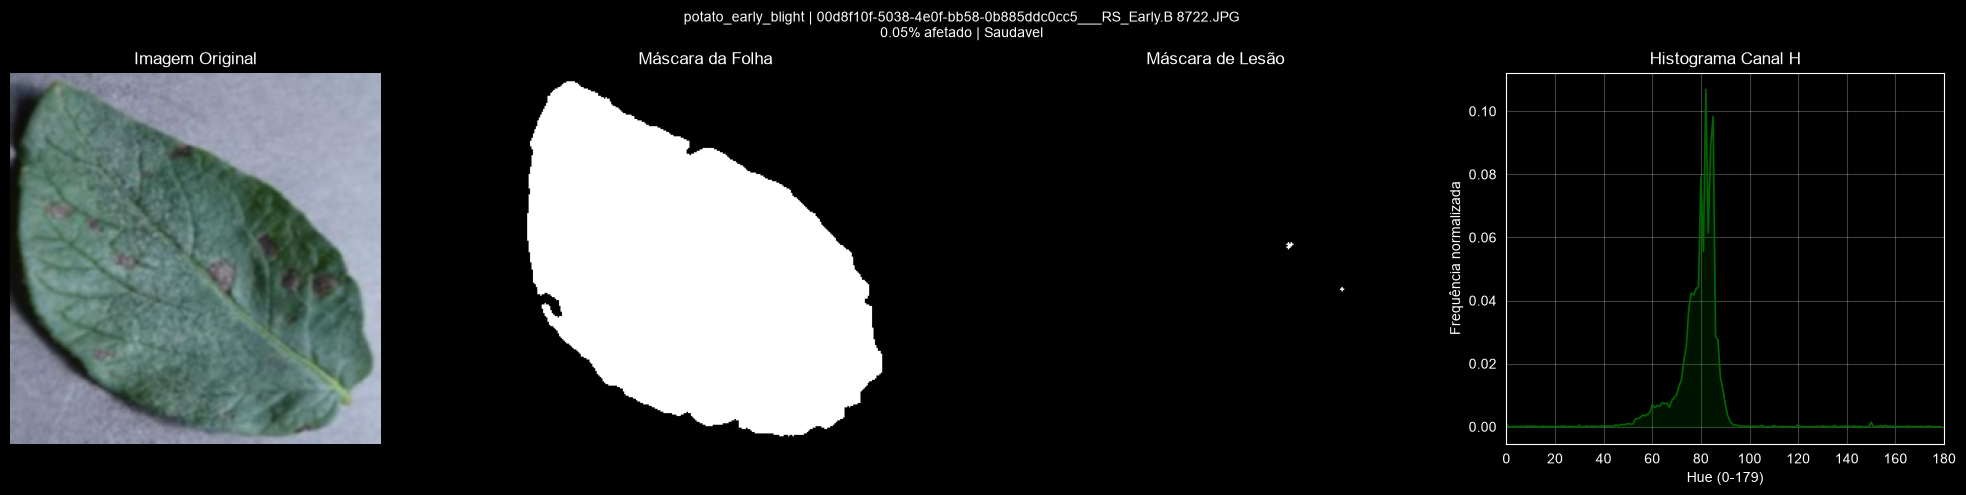

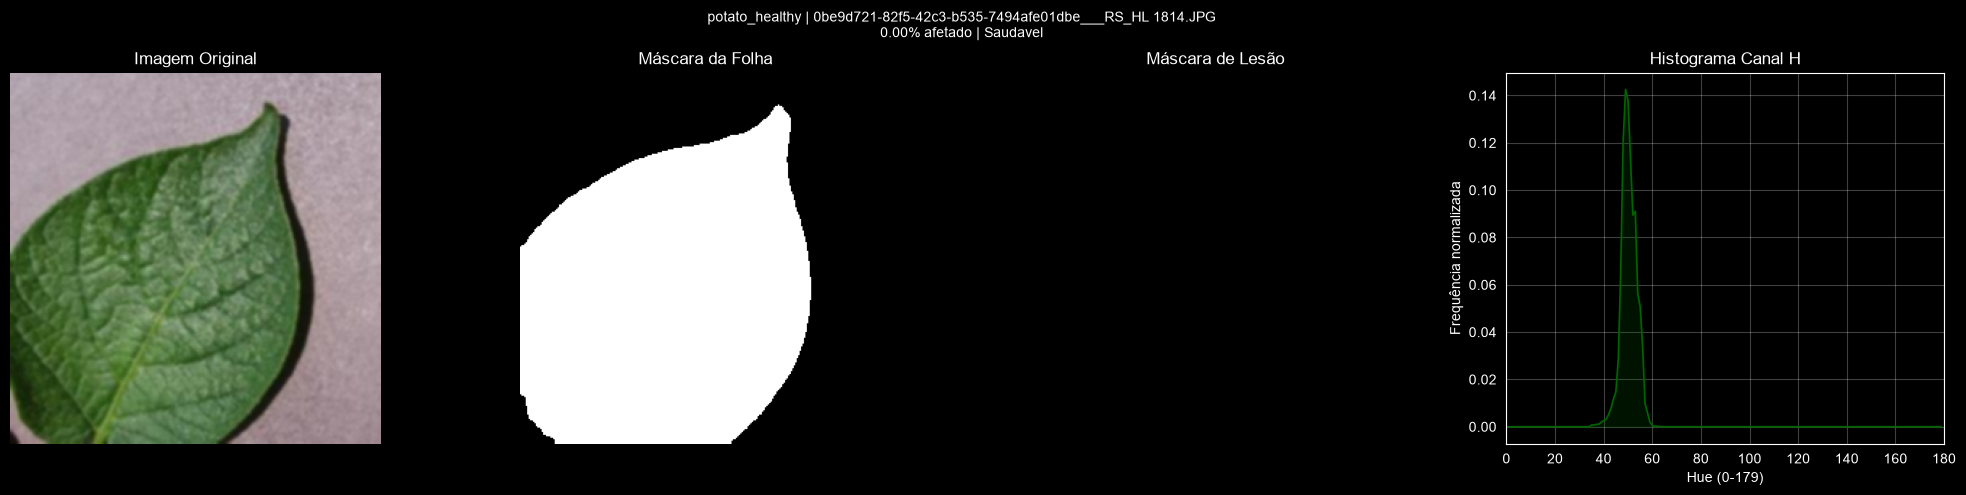

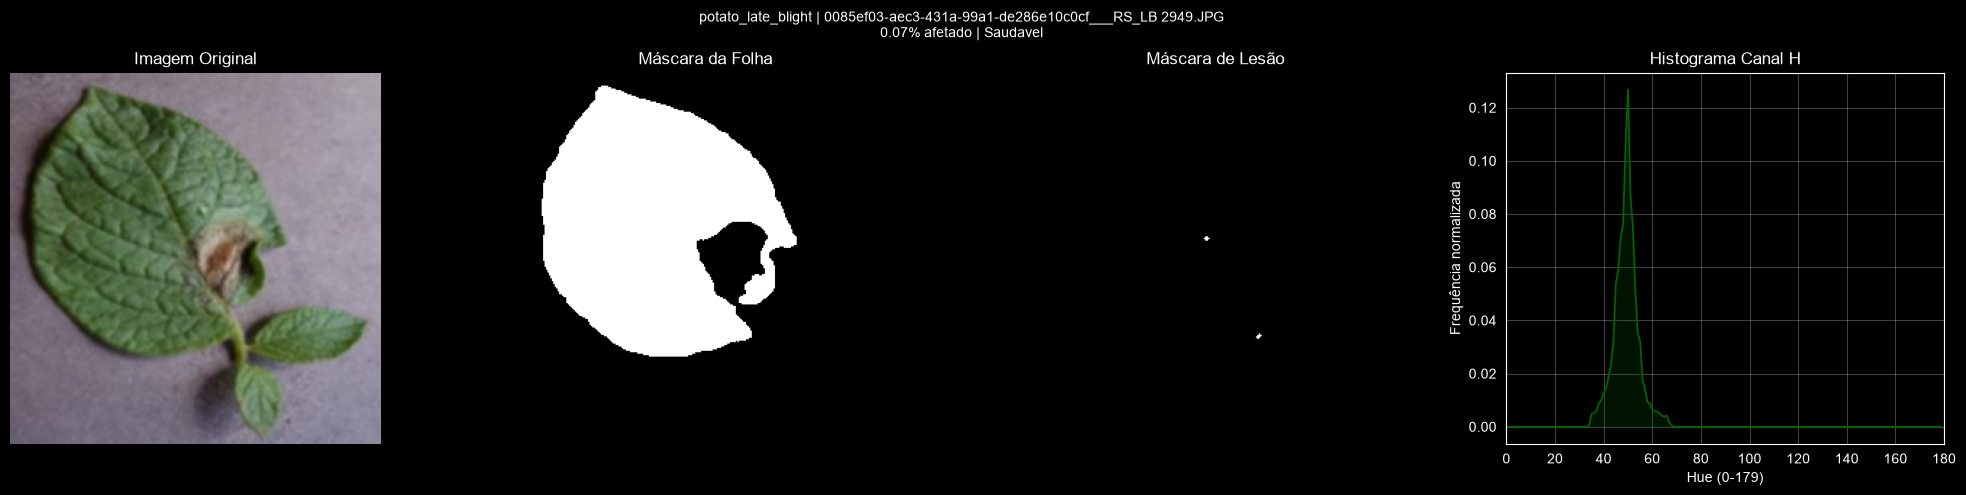

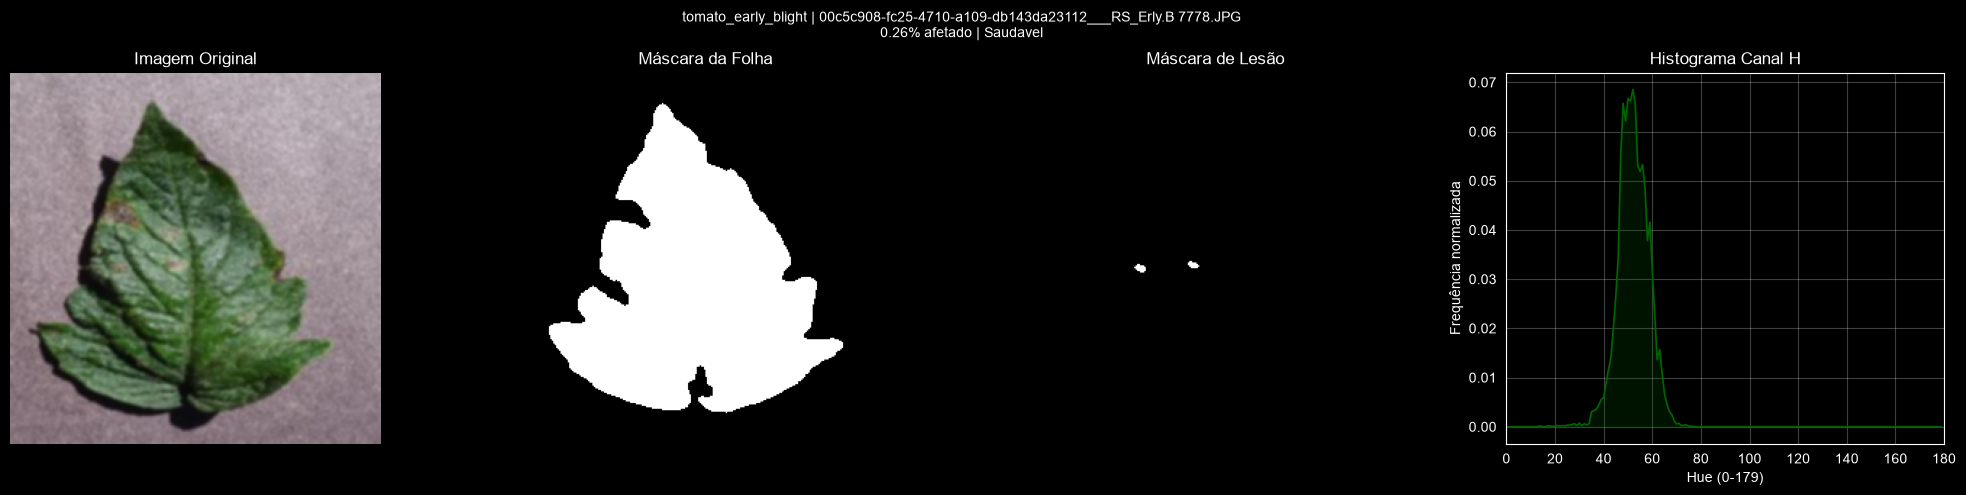

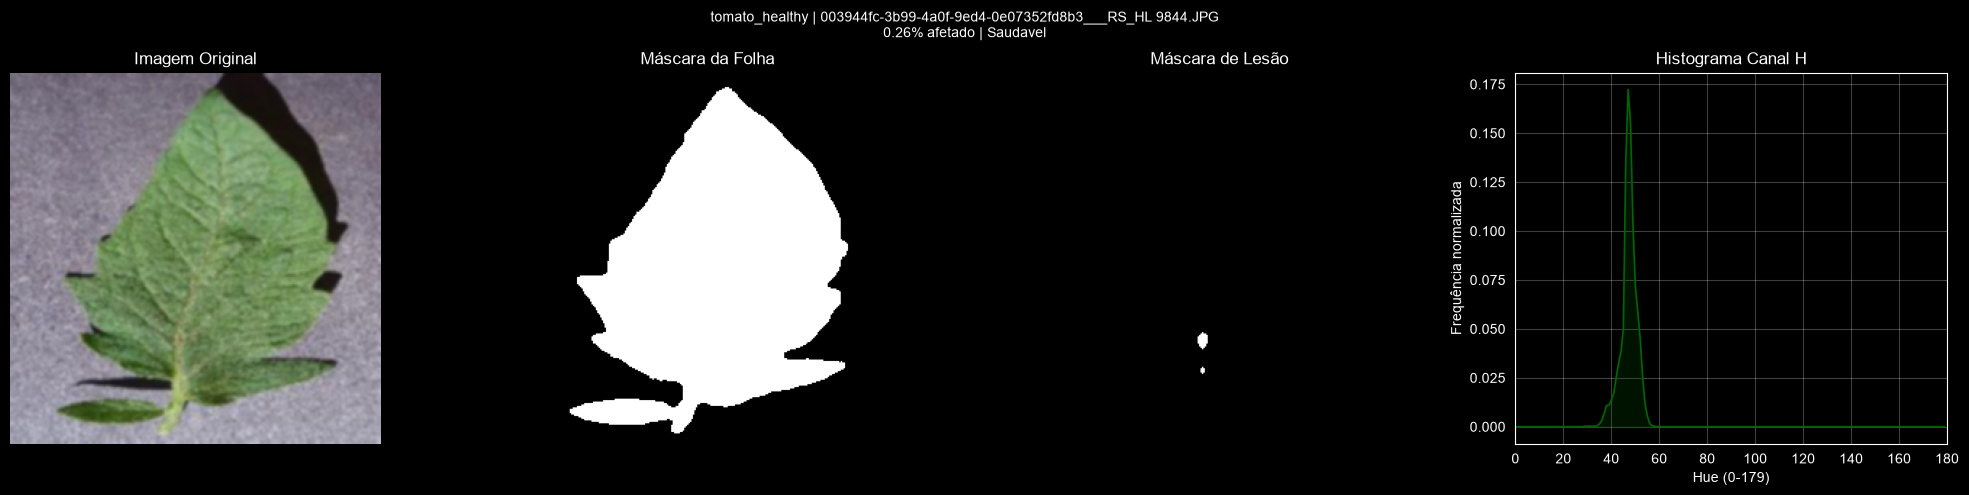

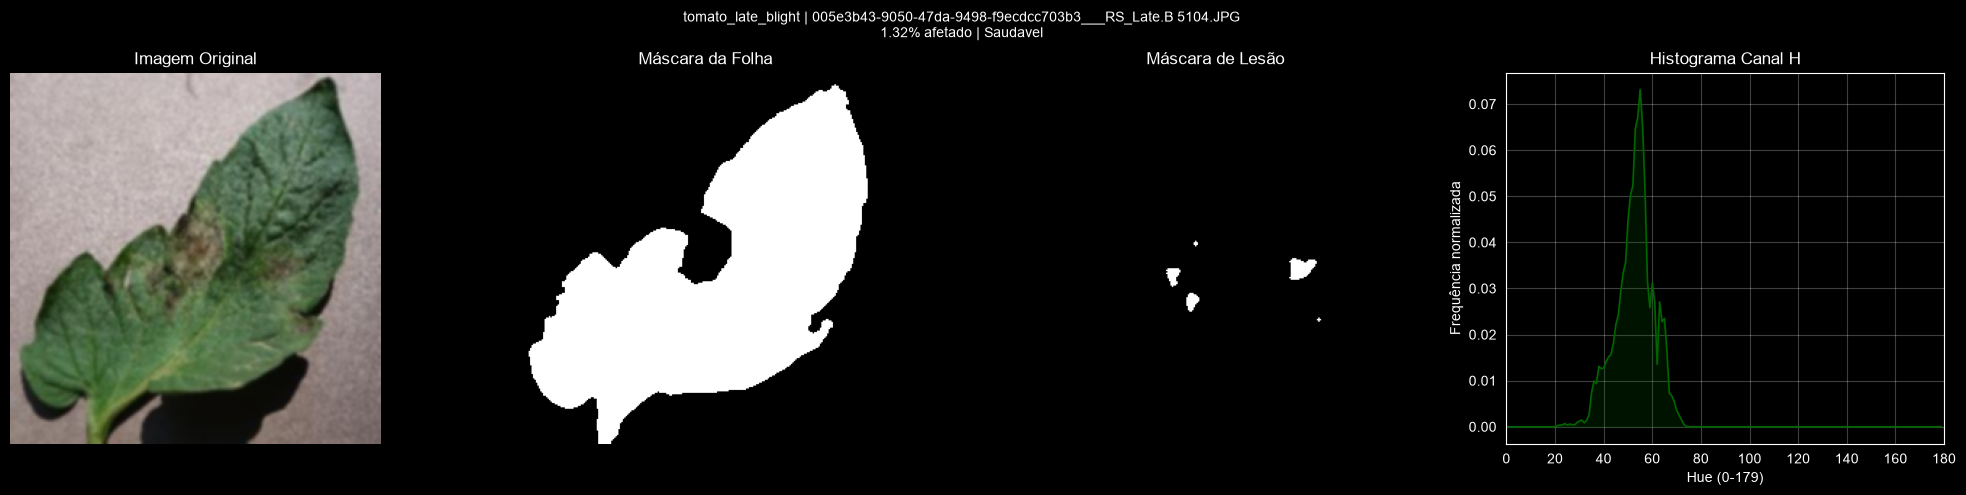

In [7]:
paths_df = pd.DataFrame(dataset_paths, columns=["path", "class"])
example_rows = []
for category in sorted(paths_df["class"].unique()):
    row = paths_df[paths_df["class"] == category].iloc[0]
    example_rows.append(row)

for row in example_rows:
    path = Path(row["path"])
    category = row["class"]
    result = process_image(str(path))
    if result["error"]:
        print(f"[ERRO] {category} | {path.name}: {result['error']}")
        continue
    fig = result["panel"]
    fig.suptitle(
        f"{category} | {path.name}\n{result['pct_affected']:.2f}% afetado | {result['severity']}",
        fontsize=10,
    )
    plt.show()

### Distribuicao do percentual afetado por categoria

O boxplot abaixo compara `pct` por categoria. Ele ajuda a observar separacao e sobreposicao entre folhas saudaveis e doentes.

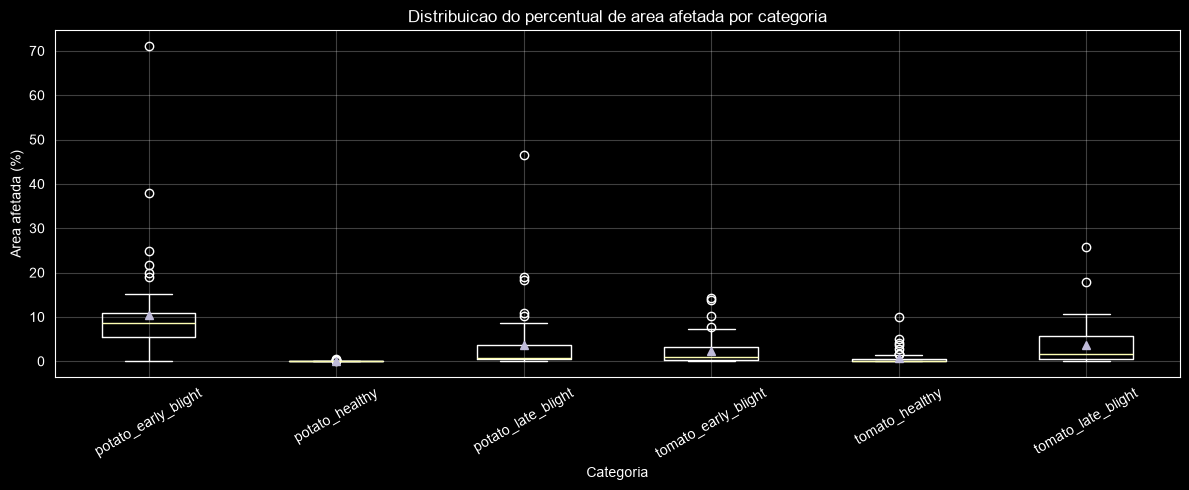

In [8]:
plot_df = df.dropna(subset=["pct"]).copy()
classes = sorted(plot_df["class"].unique())
data = [plot_df.loc[plot_df["class"] == c, "pct"] for c in classes]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(data, tick_labels=classes, showmeans=True)
ax.set_title("Distribuicao do percentual de area afetada por categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Area afetada (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Distribuicao de severidade por categoria

O grafico empilhado mostra quantas imagens de cada categoria cairam em cada nivel de severidade.

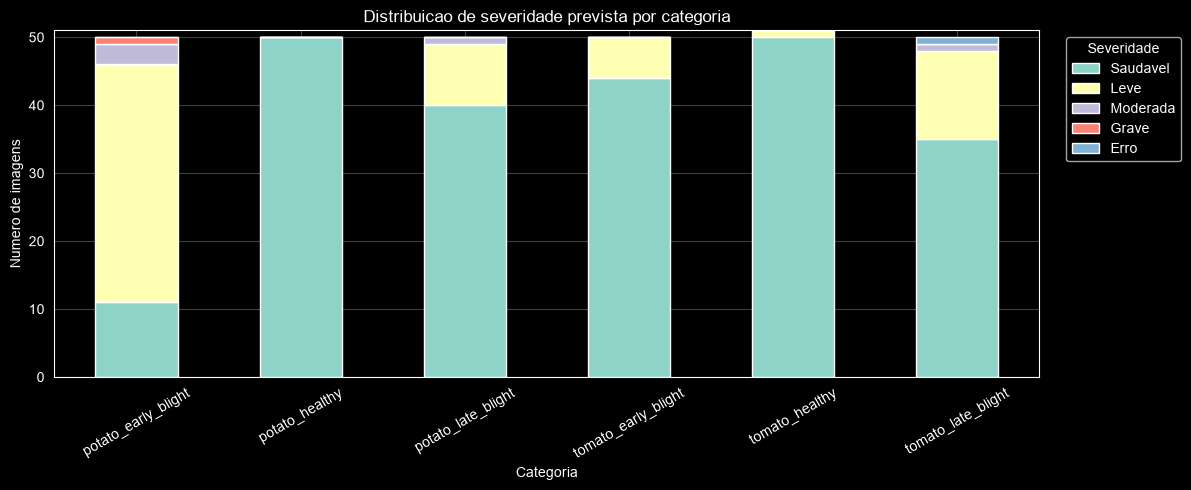

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
severity_table.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Distribuicao de severidade prevista por categoria")
ax.set_xlabel("Categoria")
ax.set_ylabel("Numero de imagens")
ax.legend(title="Severidade", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Comparacao de limiares de severidade

A configuracao padrao classifica como doente apenas quando a area afetada chega a 5%. Como muitas imagens doentes tiveram lesao detectada abaixo desse limite, testamos limiares alternativos para `leve_min`, mantendo `moderada_min=20` e `grave_min=50`. Esta comparacao nao altera os arquivos-fonte; ela usa `PipelineConfig` customizado dentro do notebook.

In [10]:
threshold_configs = {
    "padrao 5/20/50": SeverityThresholds(leve_min=5.0, moderada_min=20.0, grave_min=50.0),
    "leve_min 2%": SeverityThresholds(leve_min=2.0, moderada_min=20.0, grave_min=50.0),
    "leve_min 1%": SeverityThresholds(leve_min=1.0, moderada_min=20.0, grave_min=50.0),
    "leve_min 0.5%": SeverityThresholds(leve_min=0.5, moderada_min=20.0, grave_min=50.0),
}

comparison_rows = []
for name, thresholds in threshold_configs.items():
    cfg = PipelineConfig(gerar_painel=False, severity_thresholds=thresholds)
    cfg_results = process_batch(SELECTED_DATA_DIR, BatchConfig(pipeline_config=cfg))
    cfg_failures = analyze_failures(cfg_results)
    comparison_rows.append({
        "config": name,
        "false_positives": cfg_failures["n_false_positives"],
        "fp_rate": cfg_failures["fp_rate"],
        "false_negatives": cfg_failures["n_false_negatives"],
        "fn_rate": cfg_failures["fn_rate"],
        "errors": cfg_failures["n_erros"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,config,false_positives,fp_rate,false_negatives,fn_rate,errors
0,padrao 5/20/50,1,0.009901,130,0.653266,1
1,leve_min 2%,5,0.049505,91,0.457286,1
2,leve_min 1%,10,0.099010,72,0.361809,1
3,leve_min 0.5%,15,0.148515,51,0.256281,1


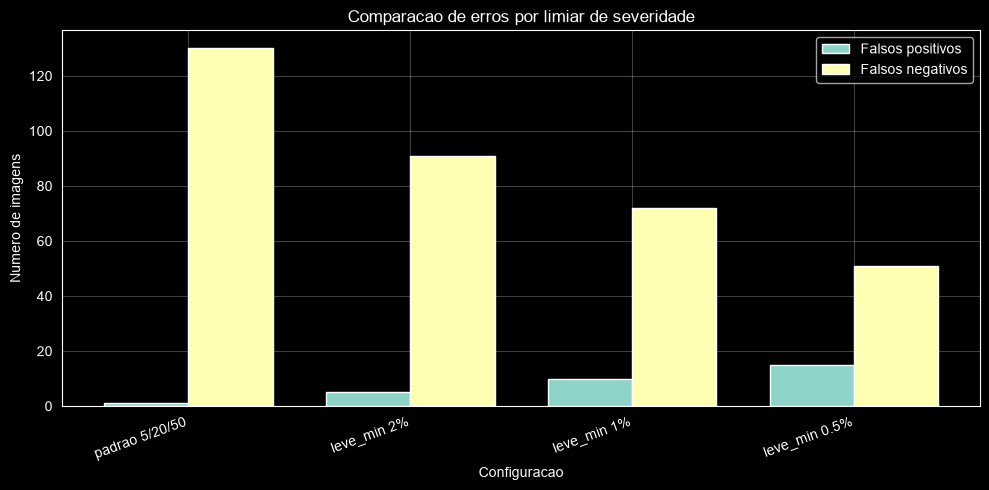

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison_df))
width = 0.38
ax.bar([i - width/2 for i in x], comparison_df["false_positives"], width=width, label="Falsos positivos")
ax.bar([i + width/2 for i in x], comparison_df["false_negatives"], width=width, label="Falsos negativos")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df["config"], rotation=20, ha="right")
ax.set_title("Comparacao de erros por limiar de severidade")
ax.set_xlabel("Configuracao")
ax.set_ylabel("Numero de imagens")
ax.legend()
plt.tight_layout()
plt.show()

## Analise de falhas (F6.3)

`analyze_failures` usa a categoria da pasta como referencia: imagens `*_healthy` deveriam ser `Saudavel`; imagens de `early_blight` ou `late_blight` deveriam ter alguma severidade diferente de `Saudavel`. As tabelas e paineis abaixo mostram casos concretos.

In [12]:
fp_df = pd.DataFrame(failures["false_positives"])
fn_df = pd.DataFrame(failures["false_negatives"])

print("Falsos positivos:")
display(fp_df.head(10) if not fp_df.empty else pd.DataFrame(columns=["image", "category", "pct_affected", "severity"]))

print("Falsos negativos (primeiros 15):")
display(fn_df.head(15) if not fn_df.empty else pd.DataFrame(columns=["image", "category", "pct_affected", "severity"]))

Falsos positivos:


,image,category,pct_affected,severity
0,96bf0aea-6bf2-4ad8-8fa9-bbbc30be4967___RS_HL 0...,tomato_healthy,9.911973,Leve


Falsos negativos (primeiros 15):


,image,category,pct_affected,severity
0,00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Earl...,potato_early_blight,0.047957,Saudavel
1,065fc68f-88c9-4fc3-b0a6-a6f5e1072eaa___RS_Earl...,potato_early_blight,4.666684,Saudavel
2,1f80f111-6a3e-4dfc-8456-0f3e9a19ae10___RS_Earl...,potato_early_blight,4.003066,Saudavel
3,2639ad26-c7e9-4bd6-8000-c002f676a4c6___RS_Earl...,potato_early_blight,2.955706,Saudavel
4,349730da-a627-4da6-90d5-707c4a3dba88___RS_Earl...,potato_early_blight,4.037499,Saudavel
5,41cc6e70-9745-413d-b13d-c4775bcdfa7c___RS_Earl...,potato_early_blight,2.824101,Saudavel
6,4ab9d59b-57ee-4e22-a6bb-d8152710fd28___RS_Earl...,potato_early_blight,3.640939,Saudavel
7,4d5d6c62-61d8-45a3-aada-3ee8bc44e1d5___RS_Earl...,potato_early_blight,2.771855,Saudavel
8,8994b76b-6e1e-42d3-b07c-99abca3fa35b___RS_Earl...,potato_early_blight,3.528824,Saudavel
9,8b20db6d-9c57-46d7-b40d-c6a809b49e07___RS_Earl...,potato_early_blight,0.000000,Saudavel


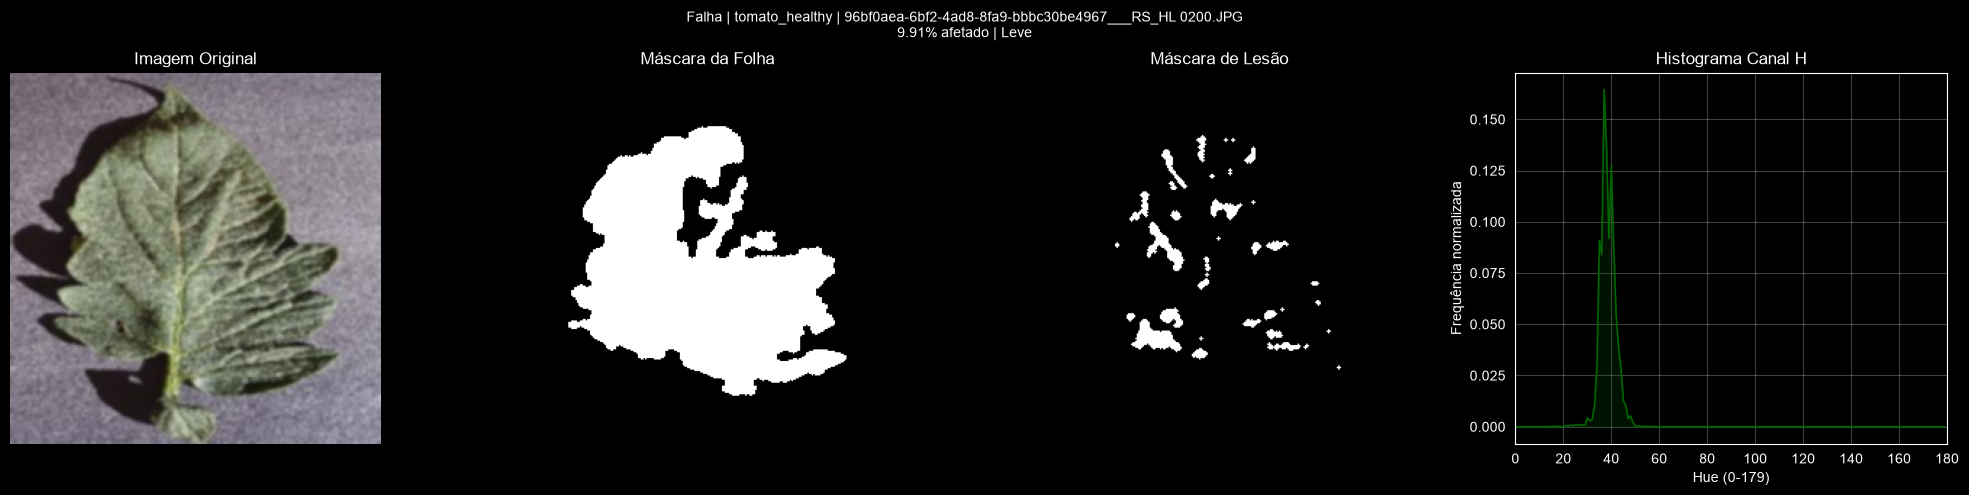

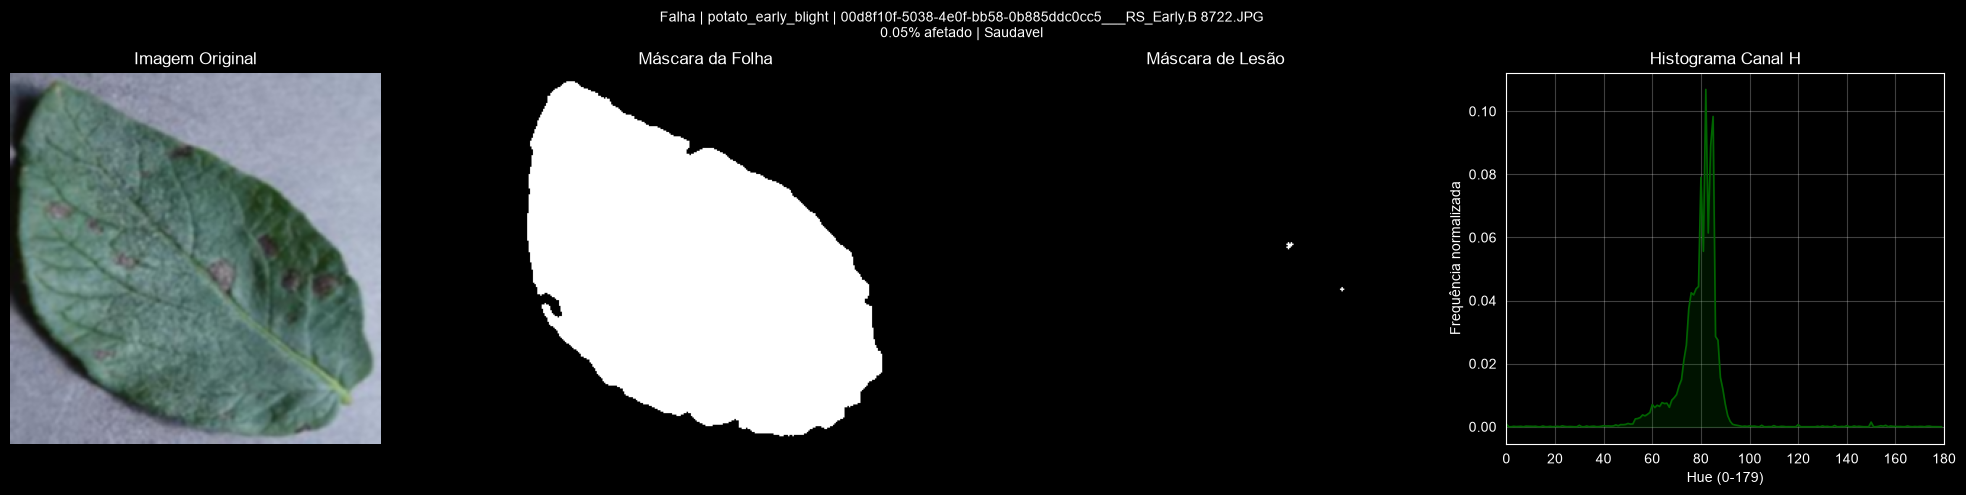

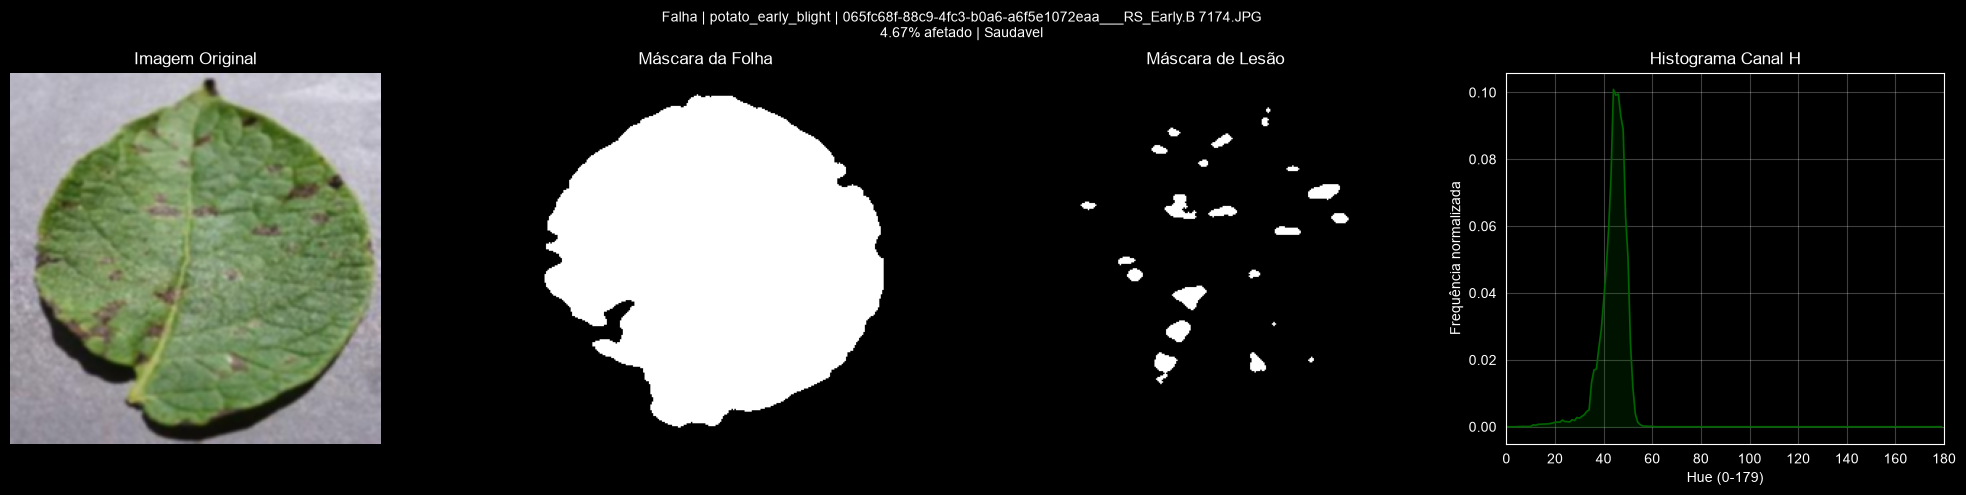

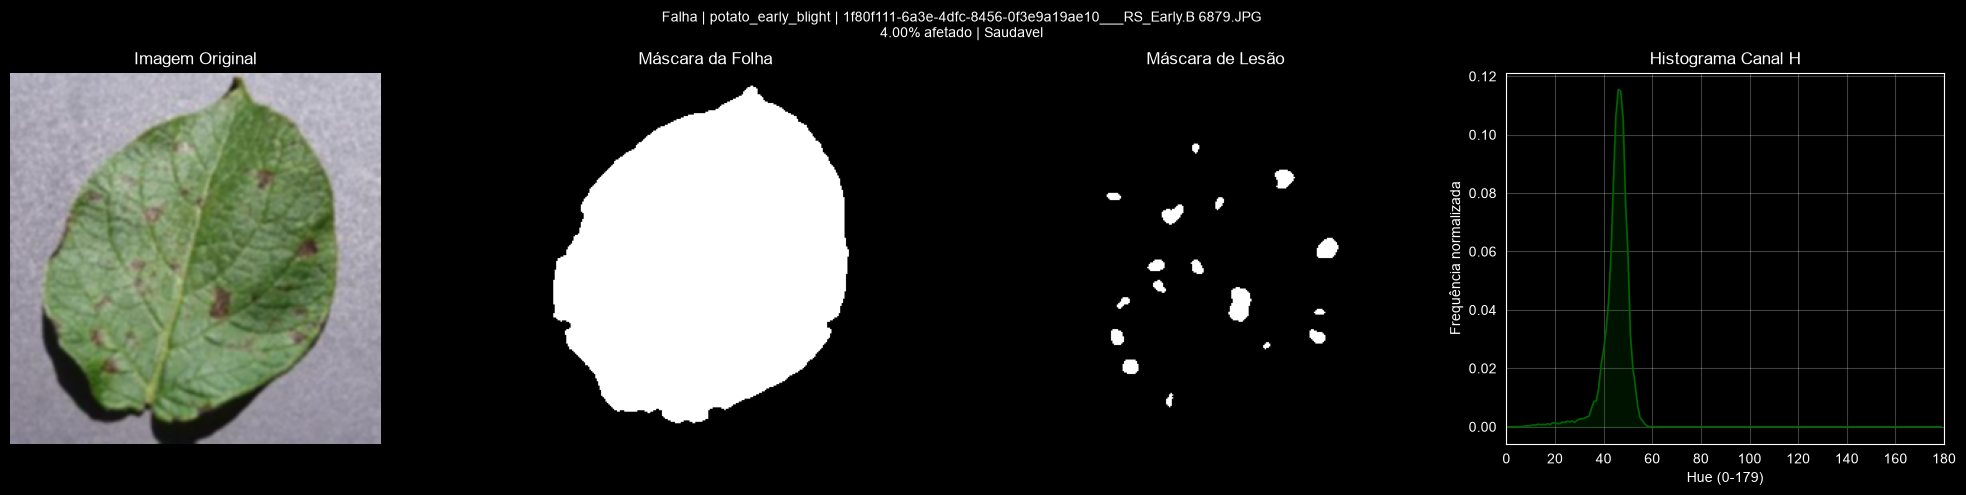

In [13]:
# Paineis especificos para discutir visualmente as falhas.
failure_examples = []
if failures["false_positives"]:
    failure_examples.append(failures["false_positives"][0])
if failures["false_negatives"]:
    failure_examples.extend(failures["false_negatives"][:3])

path_lookup = {Path(path).name: path for path, _category in dataset_paths}

for item in failure_examples:
    path = Path(path_lookup[item["image"]])
    result = process_image(str(path))
    if result["error"]:
        print(f"[ERRO] {path.name}: {result['error']}")
        continue
    fig = result["panel"]
    fig.suptitle(
        f"Falha | {item['category']} | {path.name}\n{result['pct_affected']:.2f}% afetado | {result['severity']}",
        fontsize=10,
    )
    plt.show()

## Discussao e limitacoes (F6.3)

A validacao padrao processou 301 imagens. Destas, 300 foram avaliadas e 1 gerou erro: `1507883d-7f10-4b69-88d4-db80850b1664___GHLB2 Leaf 154.JPG` na categoria `tomato_late_blight`, com falha de folha nao detectada. O erro esta ligado diretamente a decisao tecnica de F2: `segment_leaf` depende de pixels verdes dentro do range HSV 35-85 e depois `extract_largest_contour` exige um contorno verde dominante. Quando a folha tem pouco verde aproveitavel, iluminacao atipica ou lesao muito extensa, esse contorno pode nao existir.

Nos saudaveis, o metodo foi conservador: houve 1 falso positivo em folhas saudaveis. O caso `96bf0aea-6bf2-4ad8-8fa9-bbbc30be4967___RS_HL 0200.JPG`, de `tomato_healthy`, foi classificado como `Leve` com 9,91% de area afetada. No painel, a mascara de lesao aparece sobre nervuras e regioes claras/amareladas da folha. Isso decorre da decisao de F3 de incluir um range amarelo amplo (`yellow_lower=(15,40,40)` a `yellow_upper=(35,255,255)`) para capturar clorose; o mesmo range tambem captura reflexos, textura foliar e nervuras de folhas saudaveis quando essas regioes ficam amareladas.

O problema principal ficou nos falsos negativos: foram 130 imagens doentes classificadas como `Saudavel` com os limiares 5/20/50. Em `00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG`, de `potato_early_blight`, o percentual detectado foi 0,05%, apesar de haver pequenas manchas visiveis. A causa provavel e a combinacao de lesoes pequenas, baixo contraste e morfologia de F3: `refine_lesion_mask` remove ruido com abertura 3x3 e `find_lesion_contours` descarta contornos abaixo de 10 pixels, o que reduz falsos positivos mas pode apagar lesoes iniciais.

Outro falso negativo ilustrativo e `25bf1e56-4039-4d92-9a66-65b62e3b0f4d___RS_LB 4949.JPG`, de `potato_late_blight`, com 3,74% afetado e severidade `Saudavel`. Nesse caso a mascara de lesao detecta parte da regiao doente, mas o percentual fica abaixo do limiar de 5%. Aqui a falha nao esta apenas na segmentacao; ela tambem vem da regra de F4 em `classify_severity`, que usa um corte fixo e conservador. Doencas visualmente presentes, mas pequenas em relacao a area total da folha, continuam abaixo do primeiro nivel.

A comparacao de limiares confirma essa troca. Com a configuracao padrao 5/20/50, houve 1 falso positivo e 130 falsos negativos. Reduzir `leve_min` para 2% diminuiu falsos negativos para 91, mas elevou falsos positivos para 5. Com `leve_min=1%`, os falsos negativos cairam para 72 e os falsos positivos subiram para 10. Com `leve_min=0,5%`, os falsos negativos cairam para 51, mas os falsos positivos chegaram a 15. Portanto, o ajuste melhora a sensibilidade, mas sacrifica especificidade. Para o relatorio, a configuracao padrao foi mantida como referencia porque preserva os limiares originais do projeto; uma versao operacional voltada a triagem precoce poderia preferir `leve_min=1%`.

Os pontos fortes do metodo sao a interpretabilidade e a velocidade. A interseccao `intersect_with_leaf` impede que pixels do fundo entrem no calculo de lesao, e a area afetada e sempre medida em relacao a mascara foliar, nao ao tamanho total da imagem. O painel com histograma H tambem torna o diagnostico visual auditavel: e possivel ver quando o pico de verde domina e quando ha massa adicional nos tons amarelos/marrons.

As limitacoes seguem diretamente das escolhas tecnicas das F1-F4. A normalizacao de tamanho em `resize_to_size` facilita o processamento, mas pode reduzir lesoes muito pequenas. O `gaussian_blur` reduz ruido, mas suaviza bordas finas. Os ranges HSV manuais funcionam bem quando iluminacao e cor sao parecidas com os exemplos usados no ajuste, mas generalizam mal para sombras, brilho, folhas azuladas/cinzentas ou necroses fora dos ranges amarelo/marrom. A segmentacao da folha por verde tambem sofre quando a folha esta muito doente ou quando o fundo tem tons proximos. Por fim, os limiares fixos de severidade nao distinguem bem entre doenca leve real e pequenas regioes saudaveis amareladas.

Melhorias possiveis incluem calibracao automatica dos ranges HSV por imagem, normalizacao de iluminacao antes do HSV, uso de criterios adaptativos por especie, reducao dinamica do `min_contour_area` para detectar lesoes iniciais e um classificador supervisionado simples para separar textura saudavel de lesao real. Outra melhoria seria estimar severidade com limiares diferentes por cultura/doenca, em vez de usar o mesmo corte 5/20/50 para todos os casos.

## Conclusao

O relatorio reproduz o pipeline completo com dados reais e mostra que a abordagem classica consegue ser bastante especifica para folhas saudaveis, mas perde sensibilidade em doencas com lesoes pequenas, pouco saturadas ou abaixo de 5% da area foliar. A principal decisao para trabalhos futuros e escolher o ponto de operacao: manter a configuracao padrao para evitar alarmes falsos ou reduzir o primeiro limiar de severidade para melhorar a triagem precoce.